In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/biohub-cell-tracking-during-development/sample_submission.csv
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/7/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/47/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/17/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/81/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/19/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/22/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845

# Biohub – Cell Tracking During Development

## Chapter 14: Oracle Candidate Coverage Analysis

**Objective:** Measure how often the raw LoG detector produces at least one candidate near each ground-truth centroid. This gives an **oracle upper bound** on what any downstream ranking/filtering model could achieve.

# 🎯 Learning Objectives

By the end of this notebook, I will be able to:

- explain what **oracle candidate coverage** means
- measure how many GT centroids have at least one LoG candidate nearby
- evaluate LoG candidate coverage at multiple distance thresholds
- identify whether my bottleneck is **candidate generation** or **candidate ranking**
- visualize GT cells that raw LoG fails to cover

# 🧠 Background Theory

In Chapters 11–13, I evaluated raw LoG detection and learned filtering/ranking strategies.

A key question is still unanswered:

> When the learned model misses a GT cell, is it because:
> 1. the model ranked the wrong candidates, or
> 2. the LoG detector never generated a good candidate near that GT cell in the first place?

To answer this, I need an **oracle analysis**.

## Oracle candidate coverage
For each GT centroid, I find the distance to the **nearest LoG candidate**.

Then I ask:

- is there a LoG candidate within **3 voxels**?
- within **5 voxels**?
- within **6 voxels**?
- within **8 voxels**?

If yes, then that GT cell was at least *recoverable* by a perfect ranking model.
If no, then no ranking model could have recovered it from that candidate set.

So this notebook estimates the **maximum possible recall** available from the raw LoG candidate generator.

# 🗺️ Chapter Roadmap

This notebook will proceed in seven stages:

1. **Load the sample and GT nodes**
2. **Run raw LoG on several timepoints**
3. **Compute nearest-candidate distance for every GT centroid**
4. **Measure oracle coverage at multiple radii**
5. **Summarize oracle coverage across timepoints**
6. **Visualize GT cells with poor candidate coverage**
7. **Interpret whether the bottleneck is ranking or candidate generation**

# 📚 New Vocabulary

## Oracle Coverage
The fraction of GT cells that have at least one detector candidate within a chosen radius.

## Oracle Upper Bound
The best possible recall a perfect downstream filter/ranker could achieve, given the current candidate set.

## Candidate Generation
The process of proposing possible cell locations before filtering or tracking.

## Coverage Radius
The maximum distance allowed between a GT centroid and its nearest candidate for that GT to count as “covered.”

In [2]:
!pip install zarr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 74.8 MB/s eta 0:00:00


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from skimage.feature import blob_log

In [4]:
print("Imports successful.")

Imports successful.


# Step 1 — Load the Sample and Ground Truth

I will continue working with sample `44b6_12dfb391` so I can directly compare oracle coverage with the held-out detector behavior from Chapters 11–13.

In [5]:
competition_path = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")
train_path = competition_path / "train"

sample_id = "44b6_12dfb391"
zarr_path = train_path / f"{sample_id}.zarr"
geff_path = train_path / f"{sample_id}.geff"

# Load image volume
volume = zarr.open(zarr_path, mode="r")
image = volume["0"]   # shape: (T, Z, Y, X)

# Load graph / GT nodes
geff = zarr.open(geff_path, mode="r")

node_ids = geff["nodes/ids"][:]
t_vals = geff["nodes/props/t/values"][:]
z_vals = geff["nodes/props/z/values"][:]
y_vals = geff["nodes/props/y/values"][:]
x_vals = geff["nodes/props/x/values"][:]

nodes_df = pd.DataFrame({
    "node_id": node_ids,
    "t": t_vals,
    "z": z_vals,
    "y": y_vals,
    "x": x_vals
})

print("Image shape:", image.shape)
print("Total GT nodes:", len(nodes_df))
nodes_df.head()

Image shape: (100, 64, 256, 256)
Total GT nodes: 788


,node_id,t,z,y,x
0,106000000037,0,35,61,189
1,106000000040,0,15,194,55
2,106000000041,0,7,239,56
3,106000000043,0,27,211,109
4,106000000056,0,40,127,130


# Step 2 — Define Detection and Distance Helpers

I will use the same raw LoG detector and 3D distance utilities from earlier chapters.

In [6]:
def detect_blobs_log_3d_slicewise(
    frame_3d,
    min_sigma=2.5,
    max_sigma=3.5,
    num_sigma=3,
    threshold=0.15
):
    detections = []

    for z in range(frame_3d.shape[0]):
        slice_2d = frame_3d[z].astype(np.float32)

        s_min, s_max = slice_2d.min(), slice_2d.max()
        if s_max > s_min:
            slice_norm = (slice_2d - s_min) / (s_max - s_min)
        else:
            slice_norm = slice_2d

        blobs = blob_log(
            slice_norm,
            min_sigma=min_sigma,
            max_sigma=max_sigma,
            num_sigma=num_sigma,
            threshold=threshold
        )

        for blob in blobs:
            y, x, sigma = blob
            detections.append({
                "z": int(z),
                "y": int(round(y)),
                "x": int(round(x)),
                "sigma": float(sigma)
            })

    return pd.DataFrame(detections)

# Step 3 — Choose Timepoints for Oracle Coverage Analysis

I want to compare both earlier training-style frames and later held-out frames.

I will analyze:
- training-like frames: `t = 0, 8, 20, 40`
- held-out frames: `t = 60, 80`

In [7]:
oracle_timepoints = [0, 8, 20, 40, 60, 80]
oracle_radii = [3, 5, 6, 8]

print("Timepoints:", oracle_timepoints)
print("Coverage radii:", oracle_radii)

Timepoints: [0, 8, 20, 40, 60, 80]
Coverage radii: [3, 5, 6, 8]


# Step 4 — Define Oracle Coverage Analysis for One Timepoint

For one timepoint, I will:

1. run raw LoG
2. compute the nearest LoG candidate distance for every GT centroid
3. measure coverage at multiple radii
4. store which GT cells are covered vs uncovered

In [8]:
def oracle_coverage_for_timepoint(
    image,
    nodes_df,
    t,
    radii=(3, 5, 6, 8)
):
    frame_3d = image[t]
    gt_nodes_t = nodes_df[nodes_df["t"] == t].copy().sort_values("z")
    gt_points = gt_nodes_t[["z", "y", "x"]].to_numpy()

    pred_df = detect_blobs_log_3d_slicewise(frame_3d)

    if len(pred_df) == 0:
        gt_eval = gt_nodes_t.copy()
        gt_eval["nearest_candidate_dist"] = np.inf
        for r in radii:
            gt_eval[f"covered_r{r}"] = False

        summary_rows = []
        for r in radii:
            summary_rows.append({
                "t": t,
                "radius": r,
                "num_gt": len(gt_nodes_t),
                "num_pred": 0,
                "gt_covered": 0,
                "gt_uncovered": len(gt_nodes_t),
                "oracle_recall": 0.0
            })

        return pd.DataFrame(summary_rows), gt_eval, pred_df

    pred_points = pred_df[["z", "y", "x"]].to_numpy()
    dist = pairwise_distances_3d(gt_points, pred_points)

    min_dist_gt = dist.min(axis=1)

    gt_eval = gt_nodes_t.copy()
    gt_eval["nearest_candidate_dist"] = min_dist_gt

    summary_rows = []
    for r in radii:
        covered_mask = min_dist_gt <= r
        gt_eval[f"covered_r{r}"] = covered_mask

        summary_rows.append({
            "t": t,
            "radius": r,
            "num_gt": len(gt_nodes_t),
            "num_pred": len(pred_df),
            "gt_covered": int(covered_mask.sum()),
            "gt_uncovered": int((~covered_mask).sum()),
            "oracle_recall": covered_mask.mean()
        })

    return pd.DataFrame(summary_rows), gt_eval, pred_df

# Step 5 — Run Oracle Coverage Across Multiple Timepoints

In [9]:
def pairwise_distances_3d(gt_points, pred_points):
    gt = gt_points[:, None, :]
    pred = pred_points[None, :, :]
    distances = np.sqrt(((gt - pred) ** 2).sum(axis=2))
    return distances

In [10]:
oracle_results = []
oracle_gt_tables = {}
oracle_pred_tables = {}

for t in oracle_timepoints:
    summary_t, gt_eval_t, pred_df_t = oracle_coverage_for_timepoint(
        image=image,
        nodes_df=nodes_df,
        t=t,
        radii=oracle_radii
    )

    oracle_results.append(summary_t)
    oracle_gt_tables[t] = gt_eval_t
    oracle_pred_tables[t] = pred_df_t

oracle_results_df = pd.concat(oracle_results, ignore_index=True)
oracle_results_df

,t,radius,num_gt,num_pred,gt_covered,gt_uncovered,oracle_recall
0,0,3,10,1541,4,6,0.400000
1,0,5,10,1541,7,3,0.700000
2,0,6,10,1541,8,2,0.800000
3,0,8,10,1541,8,2,0.800000
4,8,3,11,1478,4,7,0.363636
5,8,5,11,1478,8,3,0.727273
6,8,6,11,1478,8,3,0.727273
7,8,8,11,1478,9,2,0.818182
8,20,3,9,1653,6,3,0.666667
9,20,5,9,1653,9,0,1.000000


# Step 6 — Inspect GT-to-Nearest-Candidate Distances

This table shows, for each GT centroid, how far away the nearest LoG candidate is.

In [11]:
t_inspect = 60
oracle_gt_tables[t_inspect].sort_values("nearest_candidate_dist", ascending=False)

,node_id,t,z,y,x,nearest_candidate_dist,covered_r3,covered_r5,covered_r6,covered_r8
555,166000000043,60,10,242,44,7.615773,False,False,False,True
559,166000000072,60,33,141,141,5.656854,False,False,True,True
558,166000000053,60,45,65,159,5.477226,False,False,True,True
554,166000000042,60,18,199,65,4.898979,False,True,True,True
553,166000000039,60,34,44,217,4.123106,False,True,True,True
561,166000000075,60,15,3,153,3.741657,False,True,True,True
560,166000000073,60,25,207,75,3.000000,True,True,True,True
557,166000000045,60,25,218,113,2.449490,True,True,True,True
556,166000000044,60,42,159,67,2.000000,True,True,True,True


# Step 7 — Oracle Coverage Summary Table

In [12]:
oracle_summary = oracle_results_df.pivot_table(
    index="t",
    columns="radius",
    values="oracle_recall",
    aggfunc="first"
)

oracle_summary

radius,3,5,6,8
t,,,,
0,0.400000,0.700000,0.800000,0.800000
8,0.363636,0.727273,0.727273,0.818182
20,0.666667,1.000000,1.000000,1.000000
40,0.555556,0.555556,0.666667,0.777778
60,0.333333,0.666667,0.888889,1.000000
80,0.666667,0.666667,0.666667,0.833333


# Step 8 — Plot Oracle Recall Across Timepoints

This plot shows the fraction of GT cells that have at least one LoG candidate within each radius.

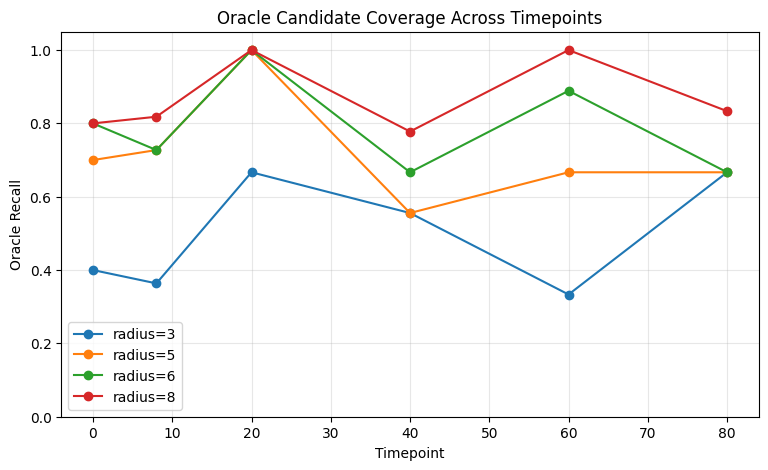

In [13]:
plt.figure(figsize=(9, 5))

for r in oracle_radii:
    df_r = oracle_results_df[oracle_results_df["radius"] == r]
    plt.plot(df_r["t"], df_r["oracle_recall"], marker="o", label=f"radius={r}")

plt.title("Oracle Candidate Coverage Across Timepoints")
plt.xlabel("Timepoint")
plt.ylabel("Oracle Recall")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Step 9 — Candidate Count Across Timepoints

This plot shows how many raw LoG detections are produced at each timepoint.

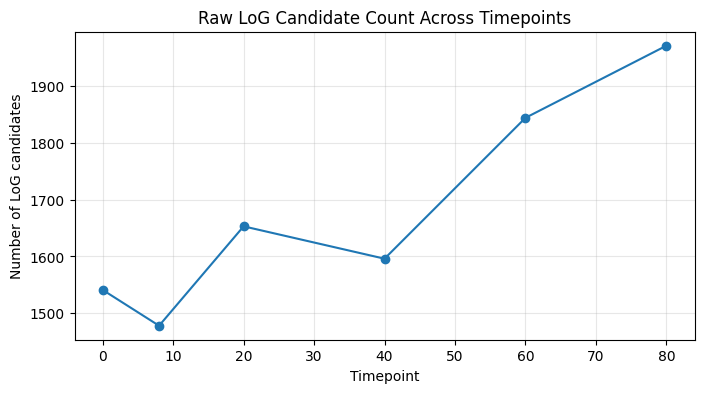

,t,num_pred
0,0,1541
4,8,1478
8,20,1653
12,40,1596
16,60,1844
20,80,1971


In [14]:
candidate_count_df = (
    oracle_results_df[["t", "num_pred"]]
    .drop_duplicates()
    .sort_values("t")
)

plt.figure(figsize=(8, 4))
plt.plot(candidate_count_df["t"], candidate_count_df["num_pred"], marker="o")
plt.title("Raw LoG Candidate Count Across Timepoints")
plt.xlabel("Timepoint")
plt.ylabel("Number of LoG candidates")
plt.grid(True, alpha=0.3)
plt.show()

candidate_count_df

# Step 10 — Average Oracle Recall by Radius

In [15]:
oracle_avg_by_radius = (
    oracle_results_df
    .groupby("radius")[["oracle_recall"]]
    .mean()
    .sort_values("oracle_recall", ascending=False)
)

oracle_avg_by_radius

,oracle_recall
radius,
8,0.871549
6,0.791582
5,0.719360
3,0.497643


# Step 11 — Visualize GT Cells Not Covered by LoG Candidates

I will visualize GT cells that do **not** have any LoG candidate within radius 6 on held-out timepoint `t = 60`.

In [16]:
t_vis = 60
radius_vis = 6

frame_vis = image[t_vis]
gt_eval_vis = oracle_gt_tables[t_vis]
pred_vis = oracle_pred_tables[t_vis]

missed_gt = gt_eval_vis[~gt_eval_vis[f"covered_r{radius_vis}"]].copy()
covered_gt = gt_eval_vis[gt_eval_vis[f"covered_r{radius_vis}"]].copy()

print(f"Timepoint {t_vis}")
print(f"GT cells not covered within radius {radius_vis}: {len(missed_gt)}")
missed_gt[["node_id", "z", "y", "x", "nearest_candidate_dist"]]

Timepoint 60
GT cells not covered within radius 6: 1


,node_id,z,y,x,nearest_candidate_dist
555,166000000043,10,242,44,7.615773


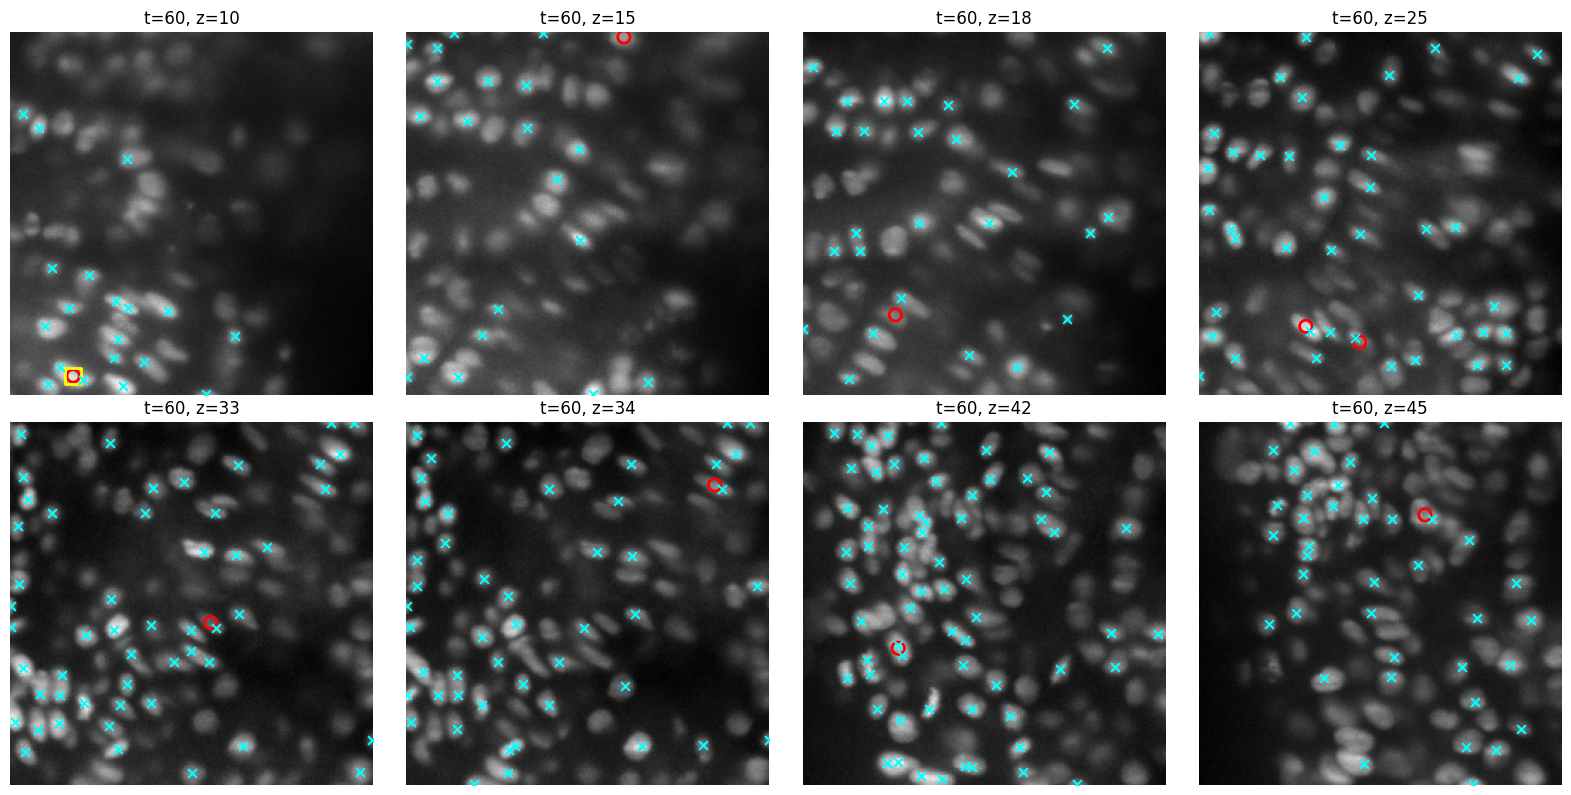

In [17]:
z_slices = sorted(gt_eval_vis["z"].unique())[:8]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, z in zip(axes, z_slices):
    slice_img = frame_vis[z]

    gt_slice_all = gt_eval_vis[gt_eval_vis["z"] == z]
    gt_slice_missed = missed_gt[missed_gt["z"] == z]
    pred_slice = pred_vis[pred_vis["z"] == z]

    ax.imshow(slice_img, cmap="gray")

    # all GT in red circles
    ax.scatter(
        gt_slice_all["x"], gt_slice_all["y"],
        facecolors="none",
        edgecolors="red",
        s=80,
        linewidths=2
    )

    # missed GT in yellow squares
    ax.scatter(
        gt_slice_missed["x"], gt_slice_missed["y"],
        facecolors="none",
        edgecolors="yellow",
        marker="s",
        s=120,
        linewidths=2
    )

    # raw LoG predictions in cyan x
    ax.scatter(
        pred_slice["x"], pred_slice["y"],
        c="cyan",
        marker="x",
        s=40
    )

    ax.set_title(f"t={t_vis}, z={z}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Step 12 — Hardest GT Cells by Nearest-Candidate Distance

These are the GT cells with the largest nearest-candidate distance.

In [18]:
hardest_gt_df = (
    gt_eval_vis
    .sort_values("nearest_candidate_dist", ascending=False)
    [["node_id", "z", "y", "x", "nearest_candidate_dist"]]
)

hardest_gt_df

,node_id,z,y,x,nearest_candidate_dist
555,166000000043,10,242,44,7.615773
559,166000000072,33,141,141,5.656854
558,166000000053,45,65,159,5.477226
554,166000000042,18,199,65,4.898979
553,166000000039,34,44,217,4.123106
561,166000000075,15,3,153,3.741657
560,166000000073,25,207,75,3.000000
557,166000000045,25,218,113,2.449490
556,166000000044,42,159,67,2.000000


# Step 13 — Interpreting Oracle Coverage

This chapter helps answer an important question:

## If oracle recall at radius 6 is high
Then raw LoG is already generating recoverable candidates near most GT cells. In that case, the main bottleneck is likely **ranking/filtering**, not candidate generation.

## If oracle recall at radius 6 is low
Then many GT cells do not even have a nearby LoG candidate. In that case, the main bottleneck is **candidate generation**, and improving ranking alone will not solve the problem.

## If oracle recall is high at radius 8 but much lower at radius 3 or 5
Then LoG is often landing near GT cells, but not precisely enough. That suggests I may need:
- better centroid localization
- 3D candidate merging
- non-maximum suppression / refinement
- a detector that predicts centers more accurately

# 📊 Results

In this chapter I measured **oracle candidate coverage** for the raw LoG detector across timepoints `t = 0, 8, 20, 40, 60, 80`.

For each GT centroid, I computed the distance to the nearest LoG candidate and measured oracle recall at radii 3, 5, 6, and 8.

## Average oracle recall across tested timepoints
- radius 3: **0.4976**
- radius 5: **0.7194**
- radius 6: **0.7916**
- radius 8: **0.8715**

## Example: held-out timepoint `t = 60`
- radius 3: **3 / 9 = 0.3333**
- radius 5: **6 / 9 = 0.6667**
- radius 6: **8 / 9 = 0.8889**
- radius 8: **9 / 9 = 1.0000**

Only one GT cell at `t = 60` lacked a LoG candidate within radius 6.

# 🔍 Analysis

This chapter showed that the raw LoG detector usually generates candidates near most GT cells, even though it also produces many false positives.

## Main findings

### 1. Raw LoG candidate generation is stronger than the learned filters
Oracle recall at radius 6 averaged about **0.79**, which is far higher than the held-out recall achieved by the learned top-k filtered detectors in Chapters 12 and 13.

### 2. Most GT cells are already recoverable from the raw candidate set
At many timepoints, a large fraction of GT cells already have a LoG candidate within radius 5–8.

### 3. The current bottleneck is mostly ranking/filtering, not candidate generation
Because GT-near candidates already exist in the raw LoG output, the poor performance of the learned filtered detector is mainly due to its inability to keep the correct candidates.

### 4. Candidate generation is still imperfect at strict radii
Oracle recall at radius 3 is only about **0.50**, so LoG often lands near GT cells without centering precisely on them. This suggests there is still room for better centroid localization or 3D candidate refinement.

# 📝 What I Learned

Today I learned that:

- oracle candidate coverage gives an upper bound on what a perfect ranking model could recover from the raw detector
- raw LoG already places candidates near most GT cells at radius 5–8
- the main failure in Chapters 12–13 was not that LoG completely missed GT cells, but that the learned filtering stage failed to preserve the recoverable ones
- the next improvement should focus on better candidate ranking, non-maximum suppression, or candidate consolidation rather than immediately replacing LoG